In [25]:
import numpy as np # for numerical operations
import pandas as pd # for data manipulation and analysis
import matplotlib.pyplot as plt # for plotting and visualization
%matplotlib inline

#importing wordcloud library for visualizing text data
from wordcloud import WordCloud

#importing NLTK library for natural language processing tasks
import nltk
from nltk.corpus import stopwords # for removing common words that do not add much meaning
from nltk.tokenize import word_tokenize # for splitting text into individual words
from nltk.stem import WordNetLemmatizer # for reducing words to their base form

# Downloading necessary NLTK resources
nltk.download('punkt') # for tokenization
nltk.download('punkt_tab') # for tokenizer tables used by newer NLTK versions
nltk.download('stopwords') # for stop words
nltk.download('wordnet') # for lemmatization

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/varshithtipirneni/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/varshithtipirneni/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/varshithtipirneni/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/varshithtipirneni/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# Read the CSV file
df = pd.read_csv('spam.csv')

# Display the first few rows of the DataFrame
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# Rename the columns name
df.rename(columns = {'v1': 'target', 'v2': 'text'}, inplace = True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Data Preprocessing

In [7]:
from sklearn.preprocessing import LabelEncoder # for encoding categorical labels into numerical format

encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.shape

(5572, 2)

In [10]:
#remove duplicates
df= df.drop_duplicates(keep = 'first')
df.shape

(5169, 2)

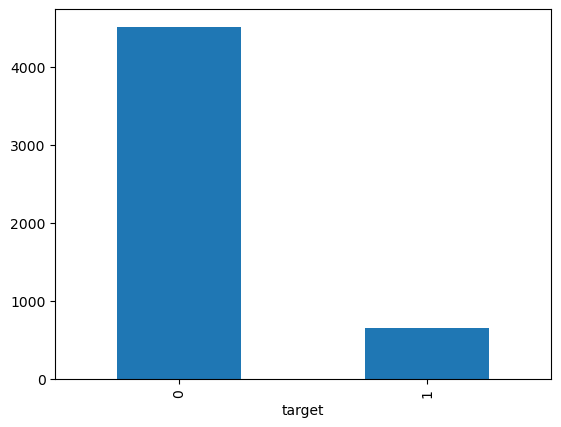

In [13]:
df['target'].value_counts().plot(kind = 'bar')
plt.show()

Feature Engg

In [26]:

# Importing the Porter Stemmer for text stemming
from nltk.stem.porter import PorterStemmer # porter stemmer is a common algorithm for reducing words to their root form

# Importing the string module for handling special characters
import string

# Creating an instance of the Porter Stemmer
ps = PorterStemmer()

In [27]:
# lowercase transformation and text preprocessing function
def transform_text(text):
    #transform text to lowercase
    text = text.lower()

    #tokenization
    text = word_tokenize(text) # splits the text into individual words (tokens) using the word_tokenize function from NLTK, punctuation and special characters are treated as separate tokens


    #remove special characters
    y = []
    for i in text:      # iterating through each token in the text
        if i.isalnum(): # checks if the token is alphanumeric (contains only letters and numbers)
            y.append(i) # if the token is alphanumeric, it is added to the list y
    #remove stop words and punctuation
    text = y[:] # creates a copy of the list y and assigns it back to text
    y.clear() # clears the list y to free up memory

    #looping through the text and removing stop words and punctuation, stop words are common words that do not add much meaning to the text (e.g., "the", "is", "in"), and punctuation is removed to focus on the actual words
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i) # if the token is not a stop word and not a punctuation mark, it is added to the list y


    #stemming using Porter Stemmer, stemming is the process of reducing words to their root form (e.g., "running" becomes "run")
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i)) # applies the Porter Stemmer to each token in the text and adds the stemmed version to the list y

    #joining the list of stemmed tokens back into a single string
    return " ".join(y) # joins the list of stemmed tokens into a single string

In [28]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [29]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [30]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
tfid = TfidfVectorizer(max_features = 500) # TfidfVectorizer is a technique for converting text data into numerical features by calculating the Term Frequency-Inverse Document Frequency (TF-IDF) values for each word in the text, max_features = 500 limits the number of features to the top 500 most important words based on their TF-IDF scores

In [31]:
X = tfid.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

Train Test Split

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

Model Training 

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score
from sklearn.model_selection import cross_val_score

In [39]:
svc = SVC(kernel= "sigmoid", gamma  = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear', penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2 )
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)    
xgb  = XGBClassifier(n_estimators = 50, random_state = 2)

In [40]:
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc,
    'Bgc': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
    
}

Model Evaluation

In [43]:
def train_classifier(clfs, X_train, y_train, X_test, y_test):
    clfs.fit(X_train,y_train)
    y_pred = clfs.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy , precision

In [44]:
accuracy_scores = []
precision_scores = []
for name , clfs in clfs.items():
    current_accuracy, current_precision = train_classifier(clfs, X_train, y_train, X_test, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)


For:  SVC
Accuracy:  0.9661508704061895
Precision:  0.9327731092436975

For:  KNN
Accuracy:  0.9274661508704062
Precision:  1.0

For:  NB
Accuracy:  0.9709864603481625
Precision:  0.9655172413793104

For:  DT
Accuracy:  0.9381044487427466
Precision:  0.9021739130434783

For:  LR
Accuracy:  0.9622823984526112
Precision:  0.9541284403669725

For:  RF
Accuracy:  0.971953578336557
Precision:  0.943089430894309


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



For:  Adaboost
Accuracy:  0.9613152804642167
Precision:  0.9375

For:  Bgc
Accuracy:  0.965183752417795
Precision:  0.9180327868852459

For:  ETC
Accuracy:  0.9729206963249516
Precision:  0.9296875

For:  GBDT
Accuracy:  0.9506769825918762
Precision:  0.9393939393939394

For:  xgb
Accuracy:  0.9709864603481625
Precision:  0.9576271186440678
